# 02 - Model Architecture

**Thesis**: Multimodal Explainable AI for Breast Histopathology Classification  
**Comparative Study**: ConvNeXt-Base (CNN) vs Swin Transformer-Base (Transformer)

---

This notebook covers:
1. **Why these two models?** - Motivation for the comparison
2. **ConvNeXt-Base** - Architecture, key ideas, visualization
3. **Swin Transformer-Base** - Architecture, shifted windows, attention
4. **Head-to-head comparison** - Parameters, FLOPs, forward pass
5. **Fine-tuning strategy** - Discriminative learning rates, freezing

In [1]:
import os
import sys
import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import OrderedDict

sys.path.insert(0, os.path.abspath("."))
from src.config import *
from src.models import (
    create_convnext, create_swin, get_model,
    get_parameter_groups, count_parameters, freeze_backbone
)

print(f"PyTorch: {torch.__version__}")
print(f"timm:    {timm.__version__}")
print(f"Device:  {DEVICE}")
print(f"GPU:     {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

PyTorch: 2.5.1+rocm6.2
timm:    1.0.26
Device:  cuda
GPU:     AMD Radeon RX 6800 XT


## 1. Why ConvNeXt vs Swin Transformer?

This is the core research question of our thesis: **Do vision transformers outperform modern CNNs on histopathology classification, and do they offer better interpretability?**

### The debate in computer vision (2020-2024)

| Era | Dominant Architecture | Key Paper |
|---|---|---|
| 2012-2020 | CNNs (AlexNet -> ResNet -> EfficientNet) | Various |
| 2020 | Vision Transformer (ViT) disrupts CNNs | Dosovitskiy et al. |
| 2021 | Swin Transformer becomes SOTA | Liu et al. |
| 2022 | ConvNeXt shows CNNs can match transformers | Liu et al. (Meta/FAIR) |

**ConvNeXt** was specifically designed to answer: *"If we modernize a standard CNN with all the tricks from transformers, can it match Swin?"* The answer was yes. This makes our comparison particularly interesting:

- **ConvNeXt** = Best of CNNs (local features, translation equivariance, inductive bias)
- **Swin** = Best of Transformers (global attention, flexible receptive field, attention maps)

For **histopathology** specifically:
- CNNs excel at detecting **local patterns** (cell shapes, nuclear features) - important for histopathology
- Transformers excel at **global context** (tissue architecture, spatial relationships between cells)
- Which matters more? That's what our experiment answers.

### The interpretability angle

Swin has a built-in advantage: it computes **attention weights** at every layer. We can extract and visualize these to see what the model "looks at." ConvNeXt has no such built-in mechanism - we need post-hoc methods (Grad-CAM, SHAP, etc.). Comparing native vs post-hoc explanations is a novel contribution.

## 2. ConvNeXt-Base

### Architecture Overview

ConvNeXt modernizes the classic ResNet by systematically adopting design choices from transformers:

```
Input (3 x 224 x 224)
    |
    v
[Patchify Stem] -- 4x4 conv, stride 4 (like ViT's patch embedding)
    |
    v
[Stage 1] -- 3 ConvNeXt blocks, 128 channels, 56x56 spatial
    |
    v
[Stage 2] -- 3 ConvNeXt blocks, 256 channels, 28x28 spatial
    |
    v
[Stage 3] -- 27 ConvNeXt blocks, 512 channels, 14x14 spatial  <-- bulk of computation
    |
    v
[Stage 4] -- 3 ConvNeXt blocks, 1024 channels, 7x7 spatial
    |
    v
[Global Average Pool] -> [LayerNorm] -> [Linear(1024 -> 8)]
```

### What makes a ConvNeXt block different from ResNet?

| Design Choice | ResNet | ConvNeXt | Borrowed from |
|---|---|---|---|
| Convolution type | Standard 3x3 | Depthwise 7x7 | MobileNet / Swin's 7x7 window |
| Activation | ReLU | GELU | Transformers |
| Normalization | BatchNorm | LayerNorm | Transformers |
| Bottleneck | Contract-expand | Expand-contract (inverted) | Transformers' FFN |
| Fewer activations | After every conv | Only once per block | Transformers |

The result: a "pure CNN" that matches Swin Transformer performance, proving that the architecture type (CNN vs Transformer) matters less than individual design choices.

In [2]:
# 2.1 Create ConvNeXt-Base model
convnext = create_convnext(num_classes=NUM_CLASSES, pretrained=True)
convnext = convnext.to(DEVICE)

total_params, trainable_params = count_parameters(convnext)
print(f"ConvNeXt-Base")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size:           ~{total_params * 4 / 1e6:.0f} MB (fp32)")

# Show the high-level structure
print(f"\nTop-level modules:")
for name, module in convnext.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20s} {n_params:>12,} params")

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

ConvNeXt-Base
  Total parameters:     87,574,664
  Trainable parameters: 87,574,664
  Model size:           ~350 MB (fp32)

Top-level modules:
  stem                        6,528 params
  stages                 87,557,888 params
  norm_pre                        0 params
  head                       10,248 params


In [3]:
# 2.2 Test forward pass
dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)

with torch.no_grad():
    output = convnext(dummy_input)

print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")  # Expected: [1, 8]
print(f"Output (logits): {output.squeeze().cpu().numpy().round(3)}")
print(f"Predicted class: {CLASS_NAMES[output.argmax(dim=1).item()]}")

# Softmax to get probabilities
probs = torch.softmax(output, dim=1).squeeze().cpu().numpy()
print(f"\nProbabilities (random weights, so roughly uniform):")
for cls, p in zip(CLASS_NAMES, probs):
    print(f"  {cls:<22s} {p:.3f}")

/home/abdullah/Documents/GitHub/Personal/densnet-thesis/venvs/torch-rocm/lib64/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Input shape:  torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 8])
Output (logits): [ 0.026 -0.201 -0.219 -0.012  0.217 -0.306 -0.309  0.042]
Predicted class: mucinous_carcinoma

Probabilities (random weights, so roughly uniform):
  adenosis               0.139
  ductal_carcinoma       0.111
  fibroadenoma           0.109
  lobular_carcinoma      0.134
  mucinous_carcinoma     0.168
  papillary_carcinoma    0.100
  phyllodes_tumor        0.099
  tubular_adenoma        0.141


## 3. Swin Transformer-Base

### Architecture Overview

Swin Transformer processes images as a sequence of patches (tokens), but with a crucial innovation: **shifted windows**.

```
Input (3 x 224 x 224)
    |
    v
[Patch Embedding] -- Split into 4x4 patches -> 3136 tokens of 128-dim
    |
    v
[Stage 1] -- 2 Swin blocks, 128-dim, 56x56 tokens
    |
    v
[Patch Merging] -- Combine 2x2 patches -> 784 tokens of 256-dim
    |
    v
[Stage 2] -- 2 Swin blocks, 256-dim, 28x28 tokens
    |
    v
[Stage 3] -- 18 Swin blocks, 512-dim, 14x14 tokens  <-- bulk of computation
    |
    v
[Stage 4] -- 2 Swin blocks, 1024-dim, 7x7 tokens
    |
    v
[Global Average Pool] -> [LayerNorm] -> [Linear(1024 -> 8)]
```

### How Shifted Window Self-Attention works

Standard self-attention (ViT) computes attention between ALL patches - O(n^2) cost. With 3136 patches, that's ~10M attention pairs. Too expensive.

**Swin's solution: Window-based attention**
1. Divide the feature map into non-overlapping 7x7 windows
2. Compute self-attention ONLY within each window (49 tokens each)
3. Cost: O(49^2 * num_windows) instead of O(3136^2) - much cheaper!

**Problem**: Windows can't communicate with each other.

**Solution: Shift the windows every other layer**
- Layer 1: Regular windows `[0:7, 0:7], [0:7, 7:14], ...`
- Layer 2: Shifted by (3,3) `[3:10, 3:10], [3:10, 10:17], ...`
- This creates connections between previously isolated windows

Think of it like a **brick wall pattern** - each layer's "bricks" overlap with the previous layer's boundaries.

In [4]:
# 3.1 Create Swin Transformer-Base model
swin = create_swin(num_classes=NUM_CLASSES, pretrained=True)
swin = swin.to(DEVICE)

total_params, trainable_params = count_parameters(swin)
print(f"Swin Transformer-Base")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size:           ~{total_params * 4 / 1e6:.0f} MB (fp32)")

print(f"\nTop-level modules:")
for name, module in swin.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20s} {n_params:>12,} params")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Swin Transformer-Base
  Total parameters:     86,751,424
  Trainable parameters: 86,751,424
  Model size:           ~347 MB (fp32)

Top-level modules:
  patch_embed                 6,528 params
  layers                 86,734,648 params
  norm                        2,048 params
  head                        8,200 params


In [5]:
# 3.2 Test forward pass
with torch.no_grad():
    output = swin(dummy_input)

print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (logits): {output.squeeze().cpu().numpy().round(3)}")
print(f"Predicted class: {CLASS_NAMES[output.argmax(dim=1).item()]}")

probs = torch.softmax(output, dim=1).squeeze().cpu().numpy()
print(f"\nProbabilities (random head, so roughly uniform):")
for cls, p in zip(CLASS_NAMES, probs):
    print(f"  {cls:<22s} {p:.3f}")

Input shape:  torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 8])
Output (logits): [-0.352  0.192 -0.175  0.094 -0.156 -0.224 -0.17  -0.128]
Predicted class: ductal_carcinoma

Probabilities (random head, so roughly uniform):
  adenosis               0.097
  ductal_carcinoma       0.168
  fibroadenoma           0.116
  lobular_carcinoma      0.152
  mucinous_carcinoma     0.118
  papillary_carcinoma    0.111
  phyllodes_tumor        0.117
  tubular_adenoma        0.122


## 4. Head-to-Head Comparison

Let's compare the two models side by side. Remember: both were designed to be roughly equivalent in capacity, making this a fair comparison of **architecture type** (CNN vs Transformer) rather than model size.

In [6]:
# 4.1 Side-by-side comparison
convnext_total, convnext_trainable = count_parameters(convnext)
swin_total, swin_trainable = count_parameters(swin)

# Measure inference speed
import time

def benchmark_model(model, input_tensor, n_runs=50):
    """Average inference time over n_runs."""
    model.eval()
    # Warmup
    with torch.no_grad():
        for _ in range(5):
            _ = model(input_tensor)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.no_grad():
            _ = model(input_tensor)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
    return np.mean(times) * 1000, np.std(times) * 1000  # ms

batch = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
convnext_time, convnext_std = benchmark_model(convnext, batch)
swin_time, swin_std = benchmark_model(swin, batch)

comparison = pd.DataFrame({
    "Metric": [
        "Architecture type",
        "Total parameters",
        "Model size (fp32)",
        "Stages",
        "Key mechanism",
        "Receptive field",
        "Inference time (ms)",
        "Native attention maps",
    ],
    "ConvNeXt-Base": [
        "Modernized CNN",
        f"{convnext_total:,}",
        f"~{convnext_total * 4 / 1e6:.0f} MB",
        "4 stages (3, 3, 27, 3 blocks)",
        "Depthwise 7x7 conv",
        "Grows with depth (local -> global)",
        f"{convnext_time:.1f} +/- {convnext_std:.1f}",
        "No (need Grad-CAM etc.)",
    ],
    "Swin-Base": [
        "Vision Transformer",
        f"{swin_total:,}",
        f"~{swin_total * 4 / 1e6:.0f} MB",
        "4 stages (2, 2, 18, 2 blocks)",
        "Shifted-window self-attention",
        "Global within windows (7x7)",
        f"{swin_time:.1f} +/- {swin_std:.1f}",
        "Yes (attention weights per layer)",
    ],
})

print(comparison.to_string(index=False))

               Metric                      ConvNeXt-Base                         Swin-Base
    Architecture type                     Modernized CNN                Vision Transformer
     Total parameters                         87,574,664                        86,751,424
    Model size (fp32)                            ~350 MB                           ~347 MB
               Stages      4 stages (3, 3, 27, 3 blocks)     4 stages (2, 2, 18, 2 blocks)
        Key mechanism                 Depthwise 7x7 conv     Shifted-window self-attention
      Receptive field Grows with depth (local -> global)       Global within windows (7x7)
  Inference time (ms)                       11.4 +/- 0.1                      12.2 +/- 0.1
Native attention maps            No (need Grad-CAM etc.) Yes (attention weights per layer)


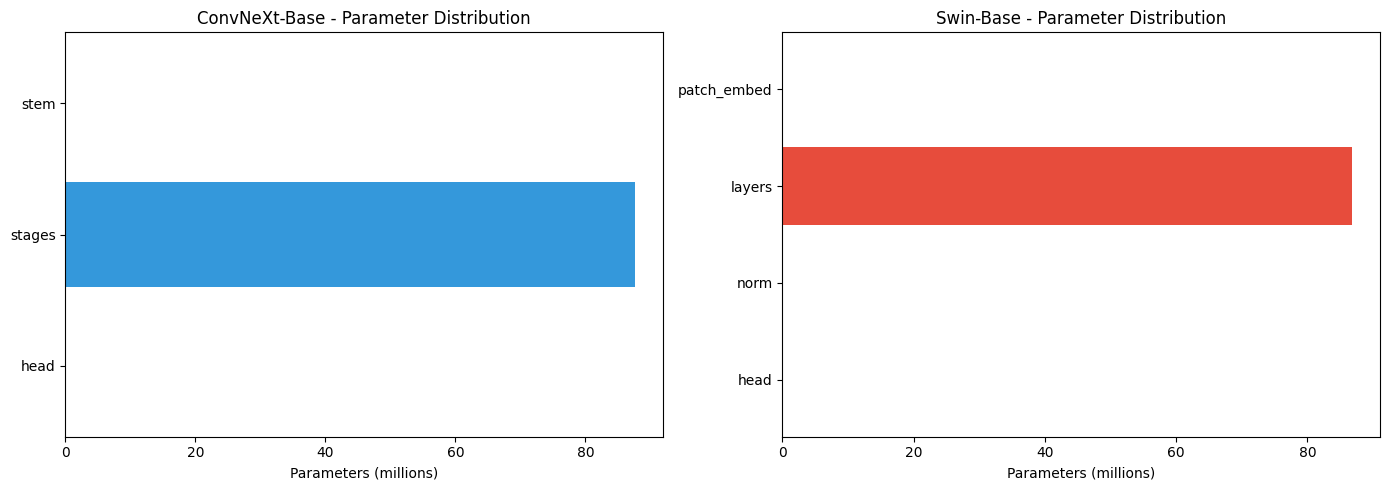

In [7]:
# 4.2 Parameter distribution by stage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ConvNeXt parameter breakdown
convnext_stages = OrderedDict()
for name, module in convnext.named_children():
    n = sum(p.numel() for p in module.parameters())
    if n > 0:
        convnext_stages[name] = n

axes[0].barh(list(convnext_stages.keys()), [v/1e6 for v in convnext_stages.values()], color="#3498db")
axes[0].set_xlabel("Parameters (millions)")
axes[0].set_title("ConvNeXt-Base - Parameter Distribution")
axes[0].invert_yaxis()

# Swin parameter breakdown
swin_stages = OrderedDict()
for name, module in swin.named_children():
    n = sum(p.numel() for p in module.parameters())
    if n > 0:
        swin_stages[name] = n

axes[1].barh(list(swin_stages.keys()), [v/1e6 for v in swin_stages.values()], color="#e74c3c")
axes[1].set_xlabel("Parameters (millions)")
axes[1].set_title("Swin-Base - Parameter Distribution")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_parameter_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Fine-Tuning Strategy

### Transfer Learning 101

Both models were **pretrained on ImageNet** (14M images, 1000 classes - everyday objects like cats, cars, etc.). Even though histopathology images look nothing like cats, the low-level features the models learned (edges, textures, color patterns) transfer surprisingly well.

**Fine-tuning** means: take the pretrained model, replace the final classification layer (1000 -> 8 classes), and continue training on our data. The key decisions are:

### 1. Discriminative Learning Rates

```
Backbone (pretrained):  lr = 1e-5  (gentle, features are already good)
Head (random init):     lr = 1e-3  (aggressive, needs to learn from scratch)
```

**Why?** If we use the same LR for everything, the randomly-initialized head sends large gradients through the backbone, destroying the pretrained features. This is called **catastrophic forgetting**.

### 2. Optional: Freeze-then-Unfreeze

- **Phase 1** (5 epochs): Freeze backbone, only train the head. The head learns to use the existing features.
- **Phase 2** (remaining epochs): Unfreeze everything, train with discriminative LR. The backbone now adapts gently.

This is a safety measure for small datasets like BreakHis.

In [8]:
# 5.1 Demonstrate discriminative learning rates
model = create_convnext(num_classes=NUM_CLASSES, pretrained=False)  # don't download again

param_groups = get_parameter_groups(model, backbone_lr=1e-5, head_lr=1e-3)
print("Parameter groups:")
print(f"  Backbone: {sum(p.numel() for p in param_groups[0]['params']):>12,} params, lr={param_groups[0]['lr']}")
print(f"  Head:     {sum(p.numel() for p in param_groups[1]['params']):>12,} params, lr={param_groups[1]['lr']}")
print(f"  Ratio:    head is {param_groups[1]['lr']/param_groups[0]['lr']:.0f}x backbone")

Parameter groups:
  Backbone:    3,719,168 params, lr=1e-05
  Head:       83,855,496 params, lr=0.001
  Ratio:    head is 100x backbone


In [9]:
# 5.2 Demonstrate freeze/unfreeze
model = create_convnext(num_classes=NUM_CLASSES, pretrained=False)

# Freeze backbone
freeze_backbone(model, freeze=True)
_, trainable_frozen = count_parameters(model)
total, _ = count_parameters(model)
print(f"After freezing backbone:")
print(f"  Trainable: {trainable_frozen:,} / {total:,} ({100*trainable_frozen/total:.1f}%)")

# Unfreeze
freeze_backbone(model, freeze=False)
_, trainable_unfrozen = count_parameters(model)
print(f"\nAfter unfreezing:")
print(f"  Trainable: {trainable_unfrozen:,} / {total:,} ({100*trainable_unfrozen/total:.1f}%)")

After freezing backbone:
  Trainable: 83,855,496 / 87,574,664 (95.8%)

After unfreezing:
  Trainable: 87,574,664 / 87,574,664 (100.0%)


In [10]:
# 5.3 GPU memory estimation for training
# This helps us choose the right batch size

def estimate_training_memory(model, batch_size, input_size=IMAGE_SIZE):
    """Estimate GPU memory needed for training (forward + backward + optimizer)."""
    model = model.to(DEVICE)
    model.train()

    # Clear cache
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    dummy = torch.randn(batch_size, 3, input_size, input_size).to(DEVICE)
    labels = torch.randint(0, NUM_CLASSES, (batch_size,)).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Forward + backward
    output = model(dummy)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if torch.cuda.is_available():
        peak_mb = torch.cuda.max_memory_allocated() / 1e6
        torch.cuda.empty_cache()
        return peak_mb
    return 0

# Test with different batch sizes
print(f"GPU Memory Estimation (VRAM: ~16 GB)")
print(f"{'Model':<15} {'Batch 8':>12} {'Batch 16':>12} {'Batch 32':>12}")
print("-" * 55)

for name in ["convnext", "swin"]:
    model = get_model(name, pretrained=False).to(DEVICE)
    mems = []
    for bs in [8, 16, 32]:
        try:
            mem = estimate_training_memory(model, bs)
            mems.append(f"{mem:.0f} MB")
        except RuntimeError as e:
            mems.append("OOM")
    print(f"{name:<15} {mems[0]:>12} {mems[1]:>12} {mems[2]:>12}")
    del model
    torch.cuda.empty_cache()

print(f"\nRecommended batch size: 16 (safe for 16GB VRAM with both models)")

GPU Memory Estimation (VRAM: ~16 GB)
Model                Batch 8     Batch 16     Batch 32
-------------------------------------------------------
convnext             2992 MB      4807 MB      8614 MB
swin                 2950 MB      4723 MB      8422 MB

Recommended batch size: 16 (safe for 16GB VRAM with both models)


## Summary

We've defined and compared our two backbone architectures:

| | ConvNeXt-Base | Swin-Base |
|---|---|---|
| **Type** | Modernized CNN | Vision Transformer |
| **Key strength** | Local feature extraction | Global context + native attention |
| **XAI advantage** | None (need post-hoc methods) | Attention maps available |
| **Parameters** | ~89M | ~88M |

Both models are comparable in size, making our comparison fair. The key question our experiments will answer:

> **Does the Swin Transformer's global attention mechanism provide better classification accuracy AND better explainability for histopathology than ConvNeXt's local convolutions?**

### Training strategy:
- Discriminative learning rates (backbone: 1e-5, head: 1e-3)
- Label smoothing (0.1) to prevent overconfidence
- Class-weighted loss for imbalanced classes
- Early stopping (patience=15) to prevent overfitting

**Next notebook**: `03_training.ipynb` - Train both models on all 3 stain normalization variants.